In [134]:
# All auxiliary code is in ../src
import sys
sys.path.append("../src/")

In [135]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [136]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint as sp_randint
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from cast_utility import cast_column_to_Int64
import seaborn as sbn
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [137]:
races=pd.read_csv('../dataset/preprocessedRaces.csv', sep=",")
placements=pd.read_csv('../dataset/preprocessedPlacements.csv', sep=",")
cyclists=pd.read_csv('../dataset/preprocessedCyclists.csv', sep=",")

In [138]:
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

### Data preparation

# Imputazione profile

In [139]:
from distribution_utility import stats_and_distribution

Description of attribute 'profile':


count     2873.0
unique       5.0
top          2.0
freq       867.0
Name: profile, dtype: float64


Unique values:
[1.0 5.0 nan 3.0 2.0 4.0]

Null values: 2408 over 5281 records - (45.60%)

Top 5 most frequent values:
profile
2.0    867
1.0    817
5.0    575
3.0    327
4.0    287
Name: count, dtype: int64


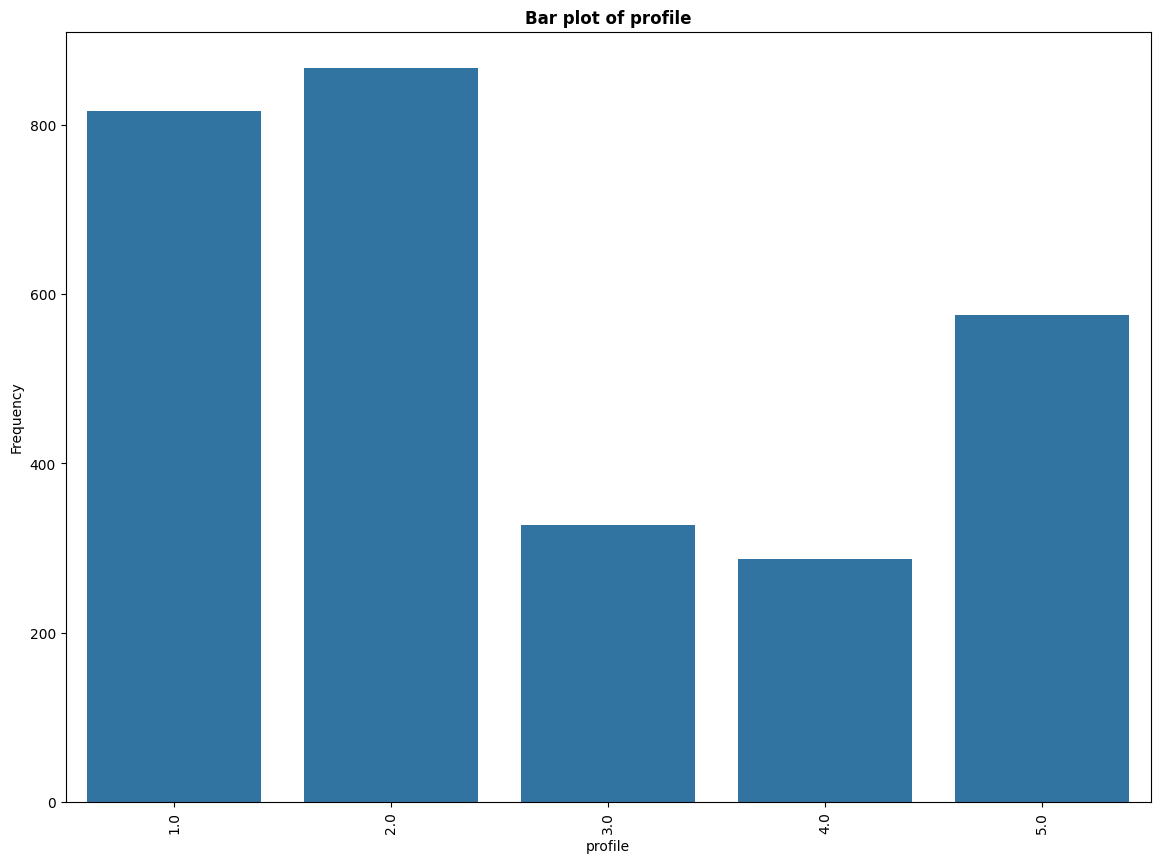

In [140]:
stats_and_distribution(races, 'profile', 'categorical')

In [141]:
races['climb/length'].isna().any()

False

In [142]:
for i in sorted(races[races['profile'].notna()]['profile'].unique()):
    print(f"----- PROFILE {i} -----")
    print(races[races['profile']==i]['climb/length'].describe())

----- PROFILE 1.0 -----
count    817.000000
mean       0.008081
std        0.004718
min        0.000069
25%        0.005191
50%        0.007845
75%        0.010229
max        0.044000
Name: climb/length, dtype: float64
----- PROFILE 2.0 -----
count    867.000000
mean       0.012952
std        0.004319
min        0.001265
25%        0.009786
50%        0.012626
75%        0.015676
max        0.046053
Name: climb/length, dtype: float64
----- PROFILE 3.0 -----
count    327.000000
mean       0.014262
std        0.004411
min        0.005415
25%        0.011479
50%        0.014025
75%        0.016459
max        0.036418
Name: climb/length, dtype: float64
----- PROFILE 4.0 -----
count    287.000000
mean       0.019497
std        0.005109
min        0.003159
25%        0.015868
50%        0.019005
75%        0.023461
max        0.032583
Name: climb/length, dtype: float64
----- PROFILE 5.0 -----
count    575.000000
mean       0.024847
std        0.011070
min        0.001901
25%        0.019022


We have decided that the imputation of the profile feature will be guided by the ratio _climb/length_, since it has a greater Kendall correlation score than the feature 'climb_total'. This result is reported in the notebook section where we have defined this novel feature. <br>
The statistics reported above show that is difficult to define ranges for the ratio in order to assign the proper 'profile' label, since there is an overlap for some profiles. For this reason the imputation is done by selecting the profile which has the nearest mean to our current climb/length ratio.

In [143]:
races_preImputation=races.copy()

In [144]:
#determine the mean clime/length ratio for each profile
profile_means = races.groupby('profile')['climb/length'].mean()
print("Mean climb/length ratio per profile\n",profile_means)

def impute_profile_by_mean(climb_length):
    # returns the index of the profile with the lowest distance with its mean value for the ratio
    return profile_means.sub(climb_length).abs().idxmin()

#imputation
races['profile'] = races['profile'].fillna(races['climb/length'].apply(impute_profile_by_mean))

Mean climb/length ratio per profile
 profile
1.0    0.008081
2.0    0.012952
3.0    0.014262
4.0    0.019497
5.0    0.024847
Name: climb/length, dtype: float64


Description of attribute 'profile':


count     5281.0
unique       5.0
top          1.0
freq      1757.0
Name: profile, dtype: float64


Unique values:
[1.0 5.0 3.0 2.0 4.0]

Null values: 0 over 5281 records - (0.00%)

Top 5 most frequent values:
profile
1.0    1757
2.0    1355
3.0     845
5.0     742
4.0     582
Name: count, dtype: int64


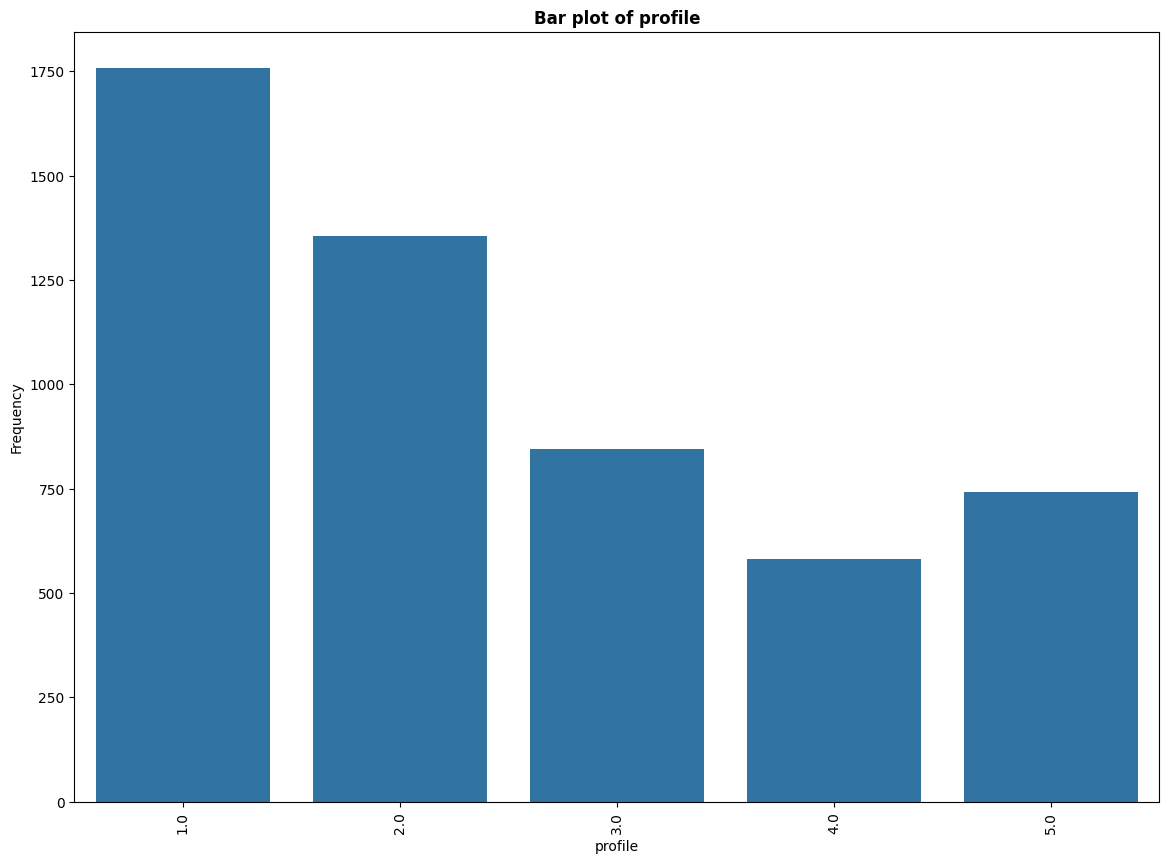

In [145]:
stats_and_distribution(races, 'profile', 'categorical')

The imputation has assigned the profile 1 to many races, in fact before the imputation the most populated profile was 2. This variation in the distribution, in some sense, cannot be avoidable since perhaps most of the races with a NaN profile have a short climb total value. Since about 42% of the races have a missing climb total information, its imputation strategy using the KNN may have influenced also the imputation of that profile.

In [146]:
import matplotlib.pyplot as plt
import seaborn as sbn
import matplotlib.colors as mcolors

def show_side_by_side_bar_plots(df1, df2, column_name):
    values1 = df1[column_name].dropna()
    values_count1 = values1.value_counts().sort_index()
    percentages1 = (values_count1 / len(values1)) * 100

    values2 = df2[column_name].dropna()
    values_count2 = values2.value_counts().sort_index()
    percentages2 = (values_count2 / len(values2)) * 100

    # Coherent palette for each graph
    unique_values = sorted(set(values1.unique()).union(set(values2.unique())))
    colors = sbn.color_palette("Set2", len(unique_values))  # A color for each unique value
    color_map = {val: colors[i] for i, val in enumerate(unique_values)} 

    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

    # First barplot (pre-imputation)
    sbn.barplot(
        x=values_count1.index, 
        y=values_count1.values, 
        ax=axes[0], 
        palette=[color_map[val] for val in values_count1.index]
    )
    axes[0].set_title(f'Bar plot of {column_name} pre-imputation', fontweight='bold')
    axes[0].set_xlabel(column_name)
    axes[0].set_ylabel('Frequency')
    for i, (v, perc) in enumerate(zip(values_count1.values, percentages1)):
        axes[0].text(i, v + max(values_count1.values) * 0.02, f'{perc:.1f}%', ha='center')

    # Second barplot (after imputation)
    sbn.barplot(
        x=values_count2.index, 
        y=values_count2.values, 
        ax=axes[1], 
        palette=[color_map[val] for val in values_count2.index]
    )
    axes[1].set_title(f'Bar plot of {column_name} after imputation', fontweight='bold')
    axes[1].set_xlabel(column_name)
    axes[1].set_ylabel('Frequency')
    for i, (v, perc) in enumerate(zip(values_count2.values, percentages2)):
        axes[1].text(i, v + max(values_count2.values) * 0.02, f'{perc:.1f}%', ha='center')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_55462/1449849370.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.barplot(
/tmp/ipykernel_55462/1449849370.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.barplot(


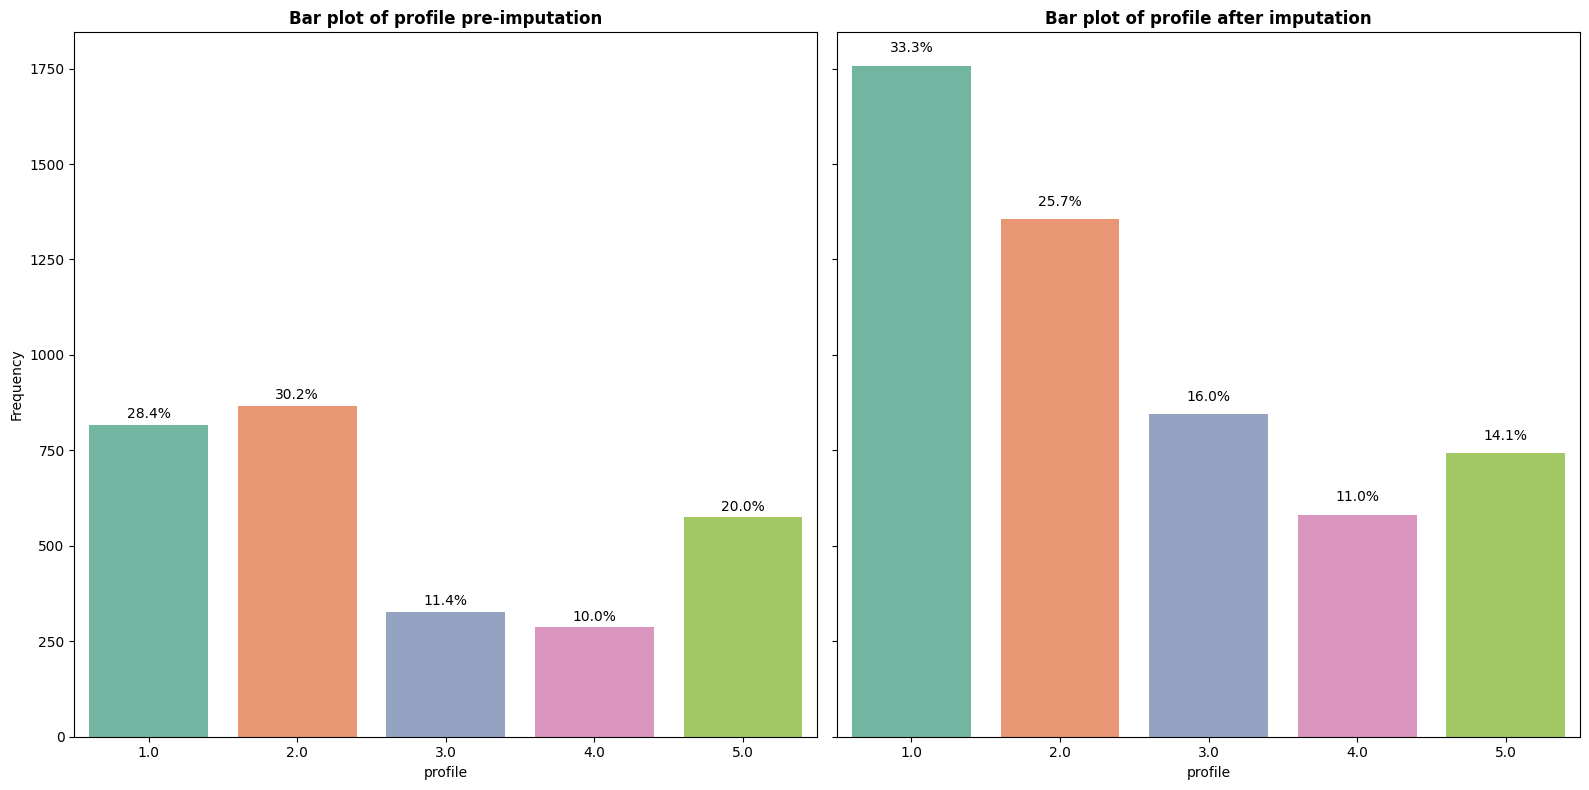

In [147]:
show_side_by_side_bar_plots(races_preImputation,races, 'profile')

#### Feature selection

Reconstruction of the original dataset by merging the three dataset produced for the previous tasks. We do not include in the final dataset those columns excluded from the analysis due not resolved data quality issues or because of redundancy. 

In [148]:
cyclists.drop(['AVG weighted position', 'AVG position Autumn', 'AVG position Spring', 'AVG position Summer', 'AVG position Winter', 'AVG position Q1', 'AVG position Q2', 'AVG position Q3', 'AVG position Q4'], axis=1, inplace=True)
cyclists.columns

Index(['name', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'nationality', 'continent', 'geo area', 'birth_year',
       'std_dev position'],
      dtype='object')

In [149]:
races.drop(['uci_points', 'average_temperature', 'is_tarmac', 'is_cobbled', 'is_gravel'], axis=1, inplace=True)
races.columns

Index(['_url', 'name', 'points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'date', 'climb/length', 'median_delta',
       'std_delta'],
      dtype='object')

In [150]:
placements.drop(['cyclist_team'], axis=1, inplace=True)
placements.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', 'date', '_url', 'year'], dtype='object')

In [151]:
placements.head()

,position,cyclist,cyclist_age,delta,date,_url,year
0,0,georges-pintens,24,0,1970-04-25,amstel-gold-race/1970/result,1970
1,1,willy-van-neste,26,0,1970-04-25,amstel-gold-race/1970/result,1970
2,2,andre-dierickx,23,22,1970-04-25,amstel-gold-race/1970/result,1970
3,3,eric-leman,24,33,1970-04-25,amstel-gold-race/1970/result,1970
4,4,joseph-schoeters,23,33,1970-04-25,amstel-gold-race/1970/result,1970


In [152]:
races.head()

,_url,name,points,length,climb_total,profile,startlist_quality,date,climb/length,median_delta,std_delta
0,tour-de-france/1978/stage-6,Tour de France,100,162000,1101,1.0,1241,1978-07-05,0.006796,27.0,6.847590
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80,196000,5575,5.0,821,2016-09-03,0.028444,1957.0,873.835670
2,tour-de-france/2019/stage-21,Tour de France,100,128000,781,1.0,1699,2019-07-28,0.006102,29.0,44.079531
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50,8100,68,1.0,804,1999-06-17,0.008395,53.0,27.154498
4,tour-de-france/2022/stage-9,Tour de France,100,192900,3743,3.0,1551,2022-07-10,0.019404,1376.0,675.354230


In [153]:
cyclists.head()

,name,BMI,median position,AVG position,# cyclist races,nationality,continent,geo area,birth_year,std_dev position
0,sean-kelly,23.770000,6,16,629,Ireland,Europe,Northern Europe,1956.0,24.497844
1,gerrie-knetemann,19.959003,38,48,271,Netherlands,Europe,Western Europe,1951.0,46.993017
2,rene-bittinger,22.790000,42,47,146,France,Europe,Western Europe,1954.0,32.648452
3,joseph-bruyere,23.086015,8,16,48,Belgium,Europe,Western Europe,1948.0,19.723611
4,sven-ake-nilsson,21.300000,25,33,145,Sweden,Europe,Northern Europe,1951.0,26.276978


Reconstruction of the original dataset including the new features.

In [154]:
dataset=pd.merge(placements, races, how='inner', on='_url')
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', 'date_x', '_url', 'year',
       'name', 'points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'date_y', 'climb/length', 'median_delta',
       'std_delta'],
      dtype='object')

In [155]:
dataset.drop(['date_y', 'date_x'], axis=1, inplace=True)

In [156]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'name',
       'points', 'length', 'climb_total', 'profile', 'startlist_quality',
       'climb/length', 'median_delta', 'std_delta'],
      dtype='object')

In [157]:
dataset=pd.merge(dataset, cyclists, how='inner', left_on='cyclist', right_on='name')

In [158]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'name_x',
       'points', 'length', 'climb_total', 'profile', 'startlist_quality',
       'climb/length', 'median_delta', 'std_delta', 'name_y', 'BMI',
       'median position', 'AVG position', '# cyclist races', 'nationality',
       'continent', 'geo area', 'birth_year', 'std_dev position'],
      dtype='object')

In [159]:
dataset.drop(['name_x', 'name_y'], axis=1, inplace=True)

In [160]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'points',
       'length', 'climb_total', 'profile', 'startlist_quality', 'climb/length',
       'median_delta', 'std_delta', 'BMI', 'median position', 'AVG position',
       '# cyclist races', 'nationality', 'continent', 'geo area', 'birth_year',
       'std_dev position'],
      dtype='object')

Actually we will use our model to predict the future placements (>=2022) of the cylists, for this reason we need to adjust some statistics of the cyclists which are calculated on the whole dataset, hence considering all the placements which are in the range (1970-2023). Moreover we need to exclude those columns that, in some sense, immediately allow us to assing the proper label (such as the _'position'_ but also the _'delta'_).

In [161]:
new_stats=pd.merge(placements, cyclists, left_on='cyclist', right_on='name', how='inner')

In [162]:
print(f"# of placements: {new_stats.shape[0]}")
print(f"# of placements >=2022: {new_stats[new_stats['year']>=2022].shape[0]}")

# of placements: 589865
# of placements >=2022: 35406


In [163]:
new_stats=new_stats[['cyclist','position', 'year']]
new_stats=new_stats[new_stats['year']<2022]
new_stats

,cyclist,position,year
0,georges-pintens,0,1970
1,willy-van-neste,1,1970
2,andre-dierickx,2,1970
3,eric-leman,3,1970
4,joseph-schoeters,4,1970
...,...,...,...
589757,johan-esteban-chaves,63,2021
589758,nelson-soto,64,2021
589759,pascal-eenkhoorn,65,2021
589760,nikias-arndt,66,2021


In [164]:
print(f"# of cyclists with placements <2022 {new_stats['cyclist'].unique().shape[0]}")

# of cyclists with placements <2022 5786


In [165]:
new_stats['median position'] = new_stats.groupby('cyclist')['position'].transform(lambda x: round(x.median()))
new_stats['AVG position'] = new_stats.groupby('cyclist')['position'].transform(lambda x: round(x.mean()))
new_stats['# cyclist races'] = new_stats.groupby('cyclist')['cyclist'].transform("count")

#We needed to define this custom function because the standard one does not worked
def custom_std(x):
    return x.std() if len(x) > 1 else 0
new_stats['std_dev position'] = new_stats.groupby('cyclist')['position'].transform(custom_std)

In [166]:
print(new_stats.dtypes)
print(new_stats.isna().sum())

cyclist              object
position              int64
year                  int64
median position       int64
AVG position          int64
# cyclist races       int64
std_dev position    float64
dtype: object
cyclist             0
position            0
year                0
median position     0
AVG position        0
# cyclist races     0
std_dev position    0
dtype: int64


In [167]:
new_stats

,cyclist,position,year,median position,AVG position,# cyclist races,std_dev position
0,georges-pintens,0,1970,4,13,37,18.685480
1,willy-van-neste,1,1970,6,10,10,8.141116
2,andre-dierickx,2,1970,8,16,67,18.234961
3,eric-leman,3,1970,4,7,38,7.836705
4,joseph-schoeters,4,1970,19,20,7,9.860938
...,...,...,...,...,...,...,...
589757,johan-esteban-chaves,63,2021,33,45,373,37.031503
589758,nelson-soto,64,2021,140,118,33,47.450053
589759,pascal-eenkhoorn,65,2021,76,76,37,32.762477
589760,nikias-arndt,66,2021,88,88,343,50.876602


In [168]:
new_stats.drop(['position', 'year'], axis=1, inplace=True)
new_stats.drop_duplicates(inplace=True)
new_stats.shape[0]

5786

We notice that we have 5786 cyclists with informations related to the their races. These are less than the original number of cyclists because some of them have only participated in races after 2022 (comprised). Drop the columns containing the overall statistics and add the new stats.

In [169]:
dataset.drop(['AVG position', 'median position', '# cyclist races', 'std_dev position'], axis=1, inplace=True)

In [170]:
new_stats = new_stats.rename(columns={'median position': 'median position_2021', 
                                  'AVG position': 'AVG position_2021',
                                  '# cyclist races': '# cyclist races_2021',
                                  'std_dev position': 'std_dev position_2021'
                                  })

In [171]:
dataset

,position,cyclist,cyclist_age,delta,_url,year,points,length,climb_total,profile,startlist_quality,climb/length,median_delta,std_delta,BMI,nationality,continent,geo area,birth_year
0,0,georges-pintens,24,0,amstel-gold-race/1970/result,1970,225,240000,2611,2.0,372,0.010879,52.0,96.759863,22.057578,Belgium,Europe,Western Europe,1946.0
1,1,willy-van-neste,26,0,amstel-gold-race/1970/result,1970,225,240000,2611,2.0,372,0.010879,52.0,96.759863,18.646937,Belgium,Europe,Western Europe,1944.0
2,2,andre-dierickx,23,22,amstel-gold-race/1970/result,1970,225,240000,2611,2.0,372,0.010879,52.0,96.759863,22.840000,Belgium,Europe,Western Europe,1947.0
3,3,eric-leman,24,33,amstel-gold-race/1970/result,1970,225,240000,2611,2.0,372,0.010879,52.0,96.759863,21.748939,Belgium,Europe,Western Europe,1946.0
4,4,joseph-schoeters,23,33,amstel-gold-race/1970/result,1970,225,240000,2611,2.0,372,0.010879,52.0,96.759863,22.727257,Belgium,Europe,Western Europe,1947.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589860,98,daan-hoole,23,688,world-championship/2022/result,2022,350,266900,4167,2.0,1052,0.015613,188.0,218.624453,20.760000,Netherlands,Europe,Western Europe,1999.0
589861,99,ben-turner,23,700,world-championship/2022/result,2022,350,266900,4167,2.0,1052,0.015613,188.0,218.624453,19.660000,Great Britain,Europe,Northern Europe,1999.0
589862,100,pavel-sivakov,25,868,world-championship/2022/result,2022,350,266900,4167,2.0,1052,0.015613,188.0,218.624453,19.810000,France,Europe,Western Europe,1997.0
589863,101,jake-stewart,23,905,world-championship/2022/result,2022,350,266900,4167,2.0,1052,0.015613,188.0,218.624453,20.600000,Great Britain,Europe,Northern Europe,1999.0


In [172]:
new_stats

,cyclist,median position_2021,AVG position_2021,# cyclist races_2021,std_dev position_2021
0,georges-pintens,4,13,37,18.685480
1,willy-van-neste,6,10,10,8.141116
2,andre-dierickx,8,16,67,18.234961
3,eric-leman,4,7,38,7.836705
4,joseph-schoeters,19,20,7,9.860938
...,...,...,...,...,...
589604,lucas-eriksson,64,64,2,28.284271
589669,jakub-otruba,63,63,1,0.000000
589676,adam-toupalik,70,70,1,0.000000
589689,torstein-traeen,83,83,1,0.000000


In [173]:
dataset['cyclist'] = dataset['cyclist'].astype(str)
new_stats['cyclist'] = new_stats['cyclist'].astype(str)

We need to perform a left join since some cyclists may not have races in years before 2022. In that case, the performance columns will have a NaN value.

In [174]:
dataset=pd.merge(dataset, new_stats, how='left', on='cyclist')

In [175]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'points',
       'length', 'climb_total', 'profile', 'startlist_quality', 'climb/length',
       'median_delta', 'std_delta', 'BMI', 'nationality', 'continent',
       'geo area', 'birth_year', 'median position_2021', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021'],
      dtype='object')

In [176]:
dataset.shape[0]

589865

In [177]:
#check if there is any null value
dataset.isna().sum()

position                    0
cyclist                     0
cyclist_age                 0
delta                       0
_url                        0
year                        0
points                      0
length                      0
climb_total                 0
profile                     0
startlist_quality           0
climb/length                0
median_delta                0
std_delta                   0
BMI                         0
nationality                 0
continent                   0
geo area                    0
birth_year                  0
median position_2021     3615
AVG position_2021        3615
# cyclist races_2021     3615
std_dev position_2021    3615
dtype: int64

After this pre-processing step we have obtained a dataframe with column performances limited to 2021. For those cyclists without a race before 2022 these columns will have a NaN. Notice that not all the classifiers are able to deal with missing values, hence we need to careful consider this approach.

**NOTE SUI NAN**<br>
La gestione dei valori mancanti (NaN) nei classificatori dipende dal modello e dalla libreria utilizzata. Alcuni classificatori possono gestire i valori mancanti direttamente, mentre altri richiedono che tu li rimuova o li imputi prima dell'addestramento. <br>

**Gestione Diretta dei NaN** <br>
Alcuni algoritmi specifici possono gestire i valori mancanti senza bisogno di preprocessamento esplicito:
Alberi decisionali (e modelli basati su alberi come Random Forest, Gradient Boosting):
Molti implementano tecniche per trattare i valori mancanti, come il completamento automatico basato sui percorsi più probabili. Ad esempio: HistGradientBoosting di scikit-learn supporta direttamente i NaN.
Alcuni implementazioni di XGBoost e LightGBM gestiscono automaticamente i valori mancanti. <br>

**Classificatori che NON Gestiscono NaN** <br>
Molti modelli richiedono che i dati siano completi:
Regressione logistica, SVM, KNN, Reti neurali.

In [178]:
df_num = dataset.select_dtypes(include=["number"])
c_pearson = df_num.corr(method="pearson")['position']
c_spearman = df_num.corr(method="spearman")['position']
c_kendall = df_num.corr(method="kendall")['position']

correlations = pd.DataFrame({
    "Pearson": c_pearson,
    "Spearman": c_spearman,
    "Kendall": c_kendall
})

# Stampa i risultati in formato tabellare
print("Correlations w.r.t position")
print(correlations)

Correlations w.r.t position
                        Pearson  Spearman   Kendall
position               1.000000  1.000000  1.000000
cyclist_age            0.011969  0.008854  0.006357
delta                  0.236165  0.430059  0.299313
year                   0.142047  0.126100  0.085413
points                -0.079768  0.015253  0.011450
length                -0.012024 -0.023251 -0.015373
climb_total           -0.022597 -0.019591 -0.013095
profile               -0.011462 -0.010994 -0.007947
startlist_quality      0.147667  0.144739  0.097527
climb/length          -0.021176 -0.017952 -0.011862
median_delta           0.006928  0.003716  0.003072
std_delta              0.016092  0.041405  0.027649
BMI                    0.052756  0.050602  0.034396
birth_year             0.137308  0.127335  0.086437
median position_2021   0.453708  0.449531  0.317213
AVG position_2021      0.463757  0.457255  0.319031
# cyclist races_2021  -0.125560 -0.123631 -0.082856
std_dev position_2021  0.155666  0.1

In [179]:
#input: the dataset and the list of variables' names to encode
def categorical_columns_encoding(dataset, variables):
    for variable in variables:
        #get the unique variable's values
        var = sorted(dataset[variable].unique())
        
        #generate a mapping from the variable's values to the number representation  
        mapping = dict(zip(var, range(0, len(var) + 1)))

        #add a new colum with the number representation of the variable
        dataset[variable+'_num'] = dataset[variable].map(mapping).astype(int)
    return dataset

In [180]:
categorical_columns = ['geo area', 'nationality', 'continent']
dataset = categorical_columns_encoding(dataset, categorical_columns).drop(categorical_columns,axis=1)

Clearly we have to remove from the rows the position, that the classification model has to *predict*, but also the _delta_ that can be in some sense "cheating".

In [181]:
dataset.drop(['delta', 'median_delta', 'std_delta'], axis=1, inplace=True)
dataset.drop(['cyclist_age'], axis=1, inplace=True) #age is redundant w.r.t race_year and birth_year
dataset.drop(['nationality_num', 'continent_num'], axis=1, inplace=True) #column rendundant w.r.t geo rrea
dataset.rename(columns={'year': 'race_year'}, inplace=True)

In [182]:
dataset.head()

,position,cyclist,_url,race_year,points,length,climb_total,profile,startlist_quality,climb/length,BMI,birth_year,median position_2021,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num
0,0,georges-pintens,amstel-gold-race/1970/result,1970,225,240000,2611,2.0,372,0.010879,22.057578,1946.0,4.0,13.0,37.0,18.685480,7
1,1,willy-van-neste,amstel-gold-race/1970/result,1970,225,240000,2611,2.0,372,0.010879,18.646937,1944.0,6.0,10.0,10.0,8.141116,7
2,2,andre-dierickx,amstel-gold-race/1970/result,1970,225,240000,2611,2.0,372,0.010879,22.840000,1947.0,8.0,16.0,67.0,18.234961,7
3,3,eric-leman,amstel-gold-race/1970/result,1970,225,240000,2611,2.0,372,0.010879,21.748939,1946.0,4.0,7.0,38.0,7.836705,7
4,4,joseph-schoeters,amstel-gold-race/1970/result,1970,225,240000,2611,2.0,372,0.010879,22.727257,1947.0,19.0,20.0,7.0,9.860938,7


Let's generate the *class binary label* TOP20, which takes 1 as value if the position of the placement is in the range [0, 19], 0 otherwise.

In [183]:
dataset['top20'] = (dataset['position'] < 20).astype(int)

In [184]:
dataset[['top20', 'position']]

,top20,position
0,1,0
1,1,1
2,1,2
3,1,3
4,1,4
...,...,...
589860,0,98
589861,0,99
589862,0,100
589863,0,101


In [185]:
dataset.columns

Index(['position', 'cyclist', '_url', 'race_year', 'points', 'length',
       'climb_total', 'profile', 'startlist_quality', 'climb/length', 'BMI',
       'birth_year', 'median position_2021', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021', 'geo area_num',
       'top20'],
      dtype='object')

In [186]:
dataset.drop(['position', 'climb/length', 'cyclist', '_url'], axis=1, inplace=True)
# climb/lenght is redundant
# cyclist and url are identifiers

#### Data segmentation (Train-Test)

Test set size: 35406 (6.00%)
Training set size: 554459 (94.00%)


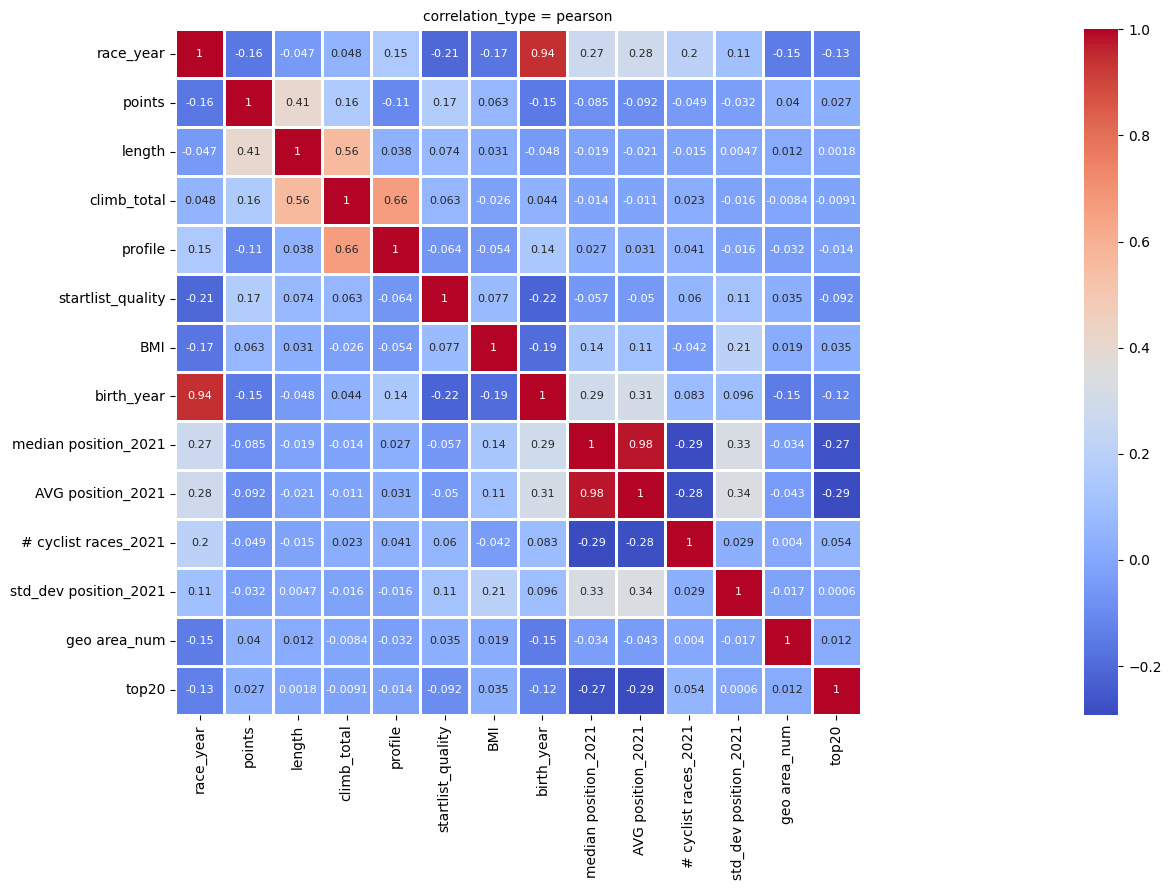

In [ ]:
from distribution_utility import show_heatmap

original_size = dataset.shape[0]
test_set = dataset[dataset['race_year']>=2022]
train_set = dataset[dataset['race_year']<2022]
print(f"Test set size: {test_set.shape[0]} ({test_set.shape[0] * 100 / original_size:.2f}%)")
print(f"Training set size: {train_set.shape[0]} ({train_set.shape[0] * 100 / original_size:.2f}%)")

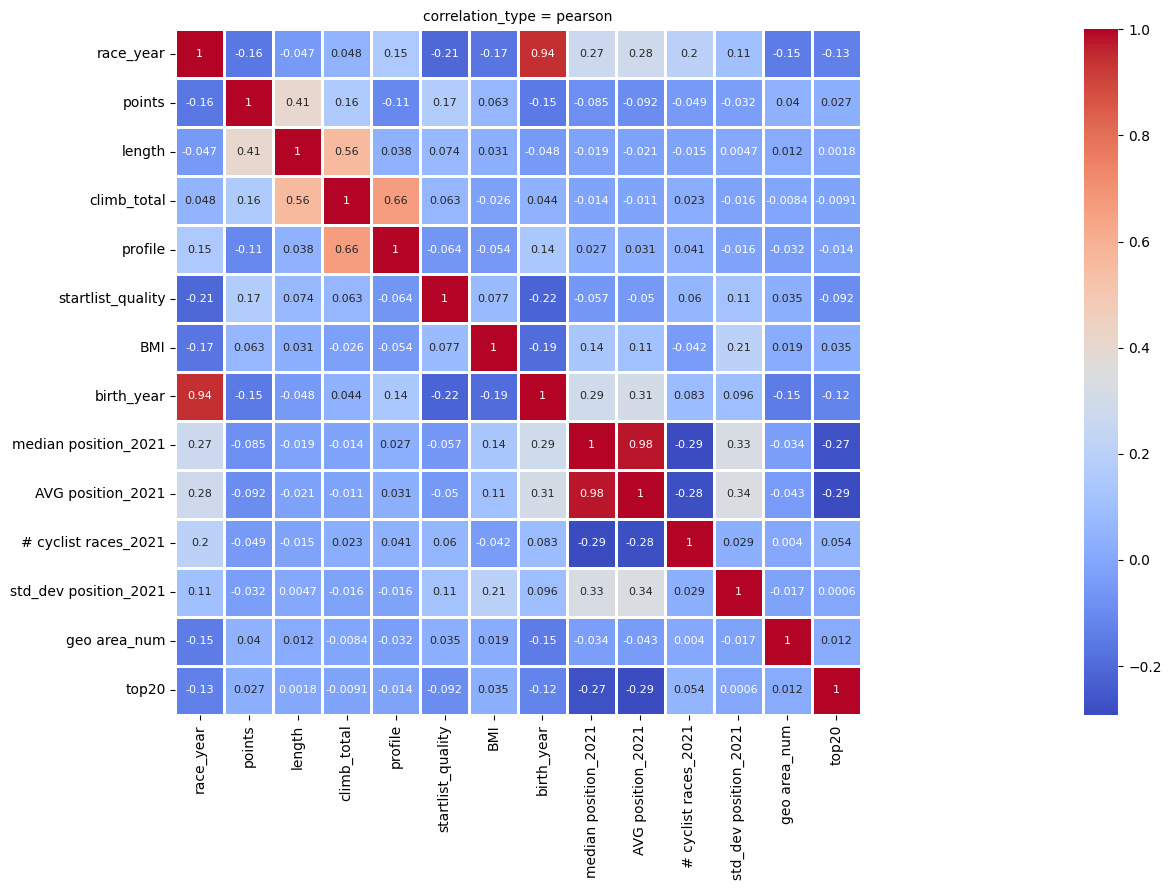

In [189]:
show_heatmap(dataset, dataset.columns, 'pearson')


The test set should never be used to perform the hyperparameter tuning and the model selection. Since we have a good number of training data, we decide to extract from it a specific _validation set_. In particular we perform a stratified train/test split in order to preserve the initial proportion between the two classes.

In [58]:
train_label = train_set.pop('top20') 
test_label = test_set.pop('top20')

# Balancing labels

In [59]:
from imblearn.under_sampling import RandomUnderSampler

undersample = RandomUnderSampler(sampling_strategy=0.6)
train_set_u, train_label_u = undersample.fit_resample(train_set, train_label)

In [ ]:
train_set_u.shape
train_label_u.value_counts(True)

top20
0    0.624999
1    0.375001
Name: proportion, dtype: float64

# SVM

## Data standardization

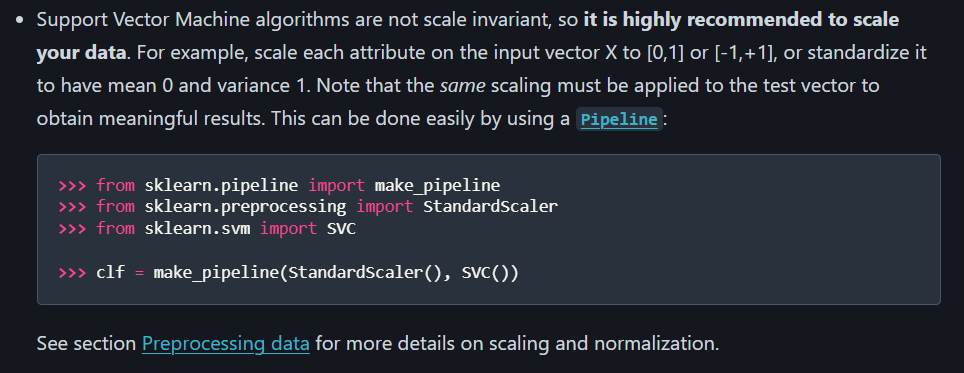

In [62]:
assert 0 == 1

AssertionError: 

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(train_set_u)
train_set_u_scaled = pd.DataFrame(scaler.transform(train_set_u), columns=train_set_u.columns)
display(train_set_u)

,race_year,points,length,climb_total,profile,startlist_quality,BMI,birth_year,median position_2021,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num
224445,1998,50,208000,3086,3.0,769,23.298883,1972.0,42.0,51.0,161.0,39.849008,7
92397,2012,80,186000,5317,4.0,886,21.050000,1984.0,95.0,86.0,229.0,48.719506,6
191710,2008,30,164500,3082,4.0,775,19.470000,1981.0,56.0,66.0,383.0,42.507185,6
40678,1996,80,220000,4772,4.0,1034,21.204357,1970.0,82.0,74.0,102.0,42.823458,6
309992,1996,100,9400,84,1.0,1872,22.716813,1966.0,68.0,68.0,103.0,41.162479,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
589709,2021,350,268300,2250,2.0,1357,21.700000,1994.0,70.0,66.0,168.0,39.817537,7
589710,2021,350,268300,2250,2.0,1357,23.550000,1989.0,102.0,96.0,163.0,43.243200,1
589711,2021,350,268300,2250,2.0,1357,20.960000,1992.0,50.0,56.0,306.0,36.273530,6
589712,2021,350,268300,2250,2.0,1357,20.060000,1995.0,95.0,90.0,99.0,47.592350,7


## Handling categorical variables

Idealmente dovremmo usare one hot encoding e non ordinal encoding come indicato qua per variabile geo area_num

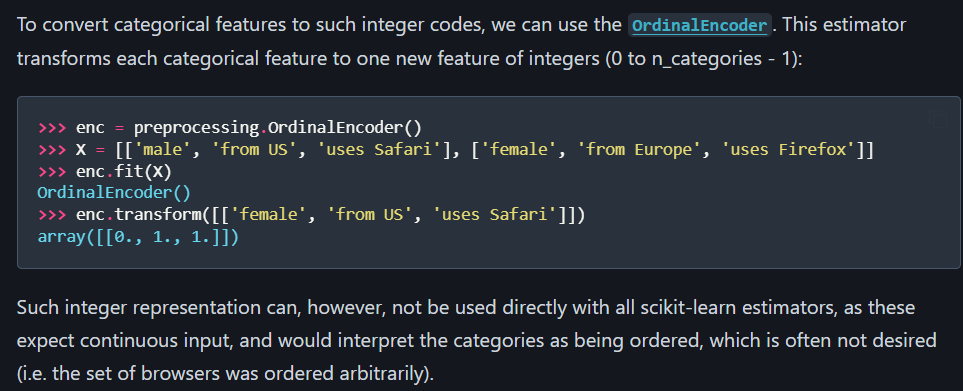

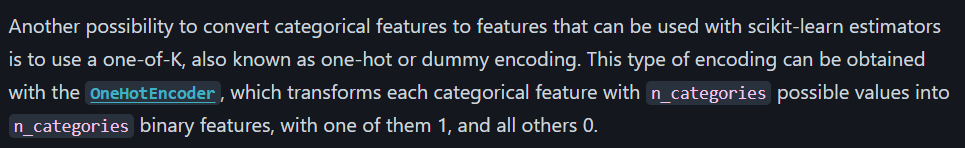

Per adesso rimuovo unicamente colonna

In [80]:
print(train_set_u_scaled.columns)
train_set_u_scaled.drop('geo area_num', axis=1, inplace=True)

Index(['race_year', 'points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'BMI', 'birth_year', 'median position_2021',
       'AVG position_2021', '# cyclist races_2021', 'std_dev position_2021'],
      dtype='object')


KeyError: "['geo area_num'] not found in axis"

Rimuovo le colonne correlate

## Execution

Come primi tentativi dividiamo manualmente i dati in train e validation e proviamo alcuni parametri

In [61]:
train_set_splitted, validation_set, train_label_splitted, validation_label = train_test_split(train_set_u_scaled, train_label_u, stratify = train_label_u, test_size=0.30)
print(train_set_splitted.size)
print(train_set_splitted[train_set_splitted.isnull().any(axis=1) == 1])

2181413
Empty DataFrame
Columns: [race_year, points, length, climb_total, profile, startlist_quality, BMI, birth_year, median position_2021, AVG position_2021, # cyclist races_2021, std_dev position_2021, geo area_num]
Index: []


In [ ]:
#linear,poly,rbf,sigmoid,precomputed
from sklearn.svm import SVC

# mappo i dati in uno spazio in cui i dati sono linearmente separabili
svm = SVC(kernel='rbf', C=0.5, gamma='scale', verbose=True)
svm.fit(train_set_splitted, train_label_splitted)

[LibSVM]...................................................